# Chapter 4 · Hierarchical MMM — borrowing strength across releases
### European label · partial pooling over 40 releases

Chapter 3 measured **one** flagship campaign with a clean geo experiment. But the label
ships **40 releases a year**, most of them small. Running a separate MMM per release is
hopeless — each has only a handful of weeks of data. Running **one** MMM for everything
ignores that a flagship and a bedroom-pop debut respond completely differently.

**Partial pooling** (a hierarchical Bayesian model) is the answer: every release gets its
own response parameters, but they're drawn from a **label-level distribution**, so small
releases **borrow strength** from the big ones. Estimates shrink toward the group — a lot
when a release has little signal, a little when it has lots.

## What this notebook shows
1. A DGP where the *true* per-release responsiveness is itself hierarchical (varies by
   artist tier + noise) — so partial pooling is the *correct* model, and we can score it.
2. Three philosophies fit head-to-head: **no pooling**, **complete pooling**, **partial
   pooling** → partial pooling recovers per-release **ROAS** best (lowest error).
3. **Calibrating the MMM with the geo experiment** from chapter 3 — the
   "experiments + MMM are complements" payoff.
4. **Budget optimization** — reallocate next year's spend across releases & channels using
   the fitted saturation curves.

> Built on **PyMC** (the engine under `pymc-marketing`) with the **nutpie** sampler. The
> hierarchical-across-releases structure is spelled out explicitly for clarity; in
> production `pymc-marketing`'s multidimensional MMM wraps the same idea.

## 1 · Setup

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
from mml import adstock, logsat

import logging; logging.disable(logging.WARNING)
import pytensor.tensor as pt, pymc as pm, arviz as az
plt.rcParams.update({"figure.figsize":(11,4.5),"figure.dpi":110,"axes.grid":True,"grid.alpha":.25,
    "axes.spines.top":False,"axes.spines.right":False,"font.size":11})
BLUE,RED,GREEN,GREY,GOLD="#3b6fb0","#d1495b","#66a182","#9e9e9e","#e8a33d"
TIERCOL={"Flagship":RED,"Mid":BLUE,"Emerging":GREEN,"Developing":GREY}
SAMPLE=dict(draws=400,tune=400,chains=2,cores=1,nuts_sampler="nutpie",progressbar=False,random_seed=1)

## 2 · DGP — 40 releases with a hierarchical truth

Each release is observed for 16 weeks. Streams = an **organic** decay baseline + a paid
**media** contribution. The media contribution scales with a release-level
**responsiveness** $\theta_r$, and crucially $\theta_r$ is drawn hierarchically:
$$\log\theta_r = \gamma\,\text{tier}_r + u_r,\qquad u_r\sim N(0,\sigma_\theta).$$
Bigger-tier acts respond more (γ), with idiosyncratic noise. Spend is **front-loaded** at
launch and bigger for bigger releases (realistic, and confounded with the baseline).

In [3]:
def make_data(seed=11):
    rng=np.random.default_rng(seed)
    roster=pd.DataFrame([("Aurora Vance","Flagship",250000,4),("Mans Eklund","Mid",70000,5),
        ("Lena Brandt","Mid",60000,4),("Theo Mercier","Mid",48000,4),("Niamh OConnor","Emerging",16000,4),
        ("Dario Conti","Emerging",13000,4),("Sofia Almeida","Emerging",10000,4),("Kai Lindqvist","Emerging",8000,4),
        ("Emile Rousseau","Developing",3000,4),("Petra Novak","Developing",2000,3)],
        columns=["artist","tier","peak","n"])
    rel=pd.DataFrame([(r.artist,r.tier,r.peak) for _,r in roster.iterrows() for _ in range(r.n)],
                     columns=["artist","tier","peak"]); rel["rid"]=range(len(rel))
    R=len(rel); W=16; chans=["tiktok","instagram"]
    d=0.18; ALPHA={"tiktok":0.5,"instagram":0.4}; LAM={"tiktok":0.8,"instagram":0.9}
    A={"tiktok":9000.0,"instagram":5000.0}
    tier_z=(np.log(rel.peak)-np.log(rel.peak).mean())/np.log(rel.peak).std()
    gamma=0.5; sig_theta=0.35; theta=np.exp(gamma*tier_z.values+rng.normal(0,sig_theta,R))
    rows=[]; truth=[]
    for i in range(R):
        peak=rel.peak[i]; wk=np.arange(W)
        base=peak*np.exp(-d*wk)*np.exp(rng.normal(0,0.05,W))
        budget=peak*0.04*np.exp(rng.normal(0,0.3)); wprof=np.exp(-0.35*wk); wprof/=wprof.sum()
        incr=np.zeros(W); spend={}
        for c in chans:
            sp=budget*{"tiktok":0.6,"instagram":0.4}[c]*wprof*np.exp(rng.normal(0,0.1,W)); spend[c]=sp
            incr+=A[c]*theta[i]*logsat(adstock(sp/1000.0,ALPHA[c]),LAM[c])
        y=base+incr+rng.normal(0,0.03*base.mean(),W); tot=sum(spend[c].sum() for c in chans)
        truth.append(dict(rid=i,tier=rel.tier[i],peak=peak,theta=theta[i],
            roas=incr.sum()/tot,lift=incr.sum()/base.sum(),spend=tot,incr=incr.sum()))
        for w in range(W):
            rows.append(dict(rid=i,artist=rel.artist[i],tier=rel.tier[i],peak=peak,week=w,
                tier_z=tier_z.values[i],streams=max(y[w],1.0),
                tiktok=spend["tiktok"][w],instagram=spend["instagram"][w]))
    meta=dict(R=R,W=W,chans=chans,ALPHA=ALPHA,LAM=LAM,A=A,d=d,gamma=gamma,sig_theta=sig_theta,roster=roster)
    return pd.DataFrame(rows),pd.DataFrame(truth),meta

df,truth,meta=make_data(); R,W,chans=meta["R"],meta["W"],meta["chans"]
print(f"{R} releases x {W} weeks = {len(df)} rows | total spend EUR {truth.spend.sum():,.0f}")
print(f"avg lift {truth.lift.mean():.1%} | median ROAS {truth.roas.median():.1f} streams/EUR")
truth.groupby("tier").agg(releases=("rid","size"),theta=("theta","mean"),
        ROAS=("roas","mean"),lift=("lift","mean")).round(2).loc[["Flagship","Mid","Emerging","Developing"]]

40 releases x 16 weeks = 640 rows | total spend EUR 83,394
avg lift 5.0% | median ROAS 5.0 streams/EUR


,releases,theta,ROAS,lift
tier,,,,
Flagship,4,3.03,15.82,0.11
Mid,13,1.58,9.12,0.06
Emerging,16,0.71,4.09,0.03
Developing,7,0.53,3.06,0.03


### Why per-release MMM is hard: the data is thin

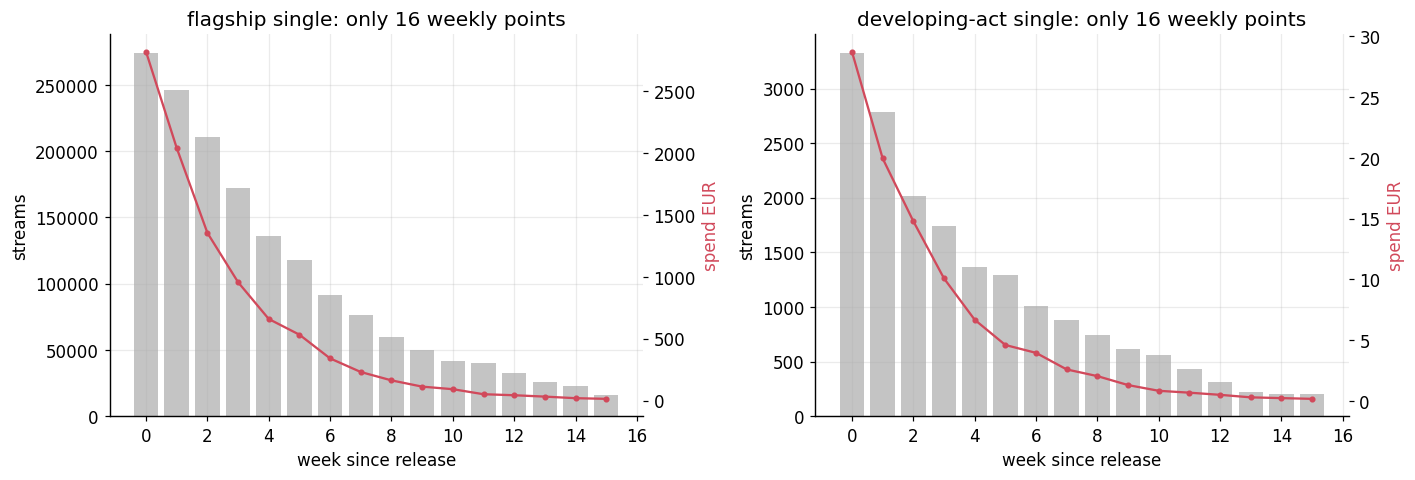

16 weekly points per release -> a standalone MMM per release is hopelessly noisy. Pool them.


In [4]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
big=truth.sort_values("incr").index[-1]; small=truth.query("tier=='Developing'").rid.iloc[0]
for ax,rid_,lab in [(a1,big,"flagship single"),(a2,small,"developing-act single")]:
    g=df[df.rid==rid_]
    ax.bar(g.week, g.streams, color=GREY, alpha=.6, label="streams")
    axb=ax.twinx(); axb.plot(g.week, g.tiktok+g.instagram, color=RED, marker="o", ms=3, label="spend")
    axb.set_ylabel("spend EUR",color=RED); axb.grid(False)
    ax.set_title(f"{lab}: only {W} weekly points"); ax.set_xlabel("week since release"); ax.set_ylabel("streams")
plt.tight_layout(); plt.show()
print("16 weekly points per release -> a standalone MMM per release is hopelessly noisy. Pool them.")

## 3 · The model

For release $r$, week $w$, channel $c$:
$$y_{rw}= \underbrace{B_r e^{-d\,w}}_{\text{organic}} \;+\; \underbrace{\sum_c A_c\,\theta_r\,\text{sat}\big(\text{adstock}(x_{rwc};\alpha_c);\lambda_c\big)}_{\text{media}}\;+\;\varepsilon_{rw}$$
with the **hierarchical** responsiveness $\log\theta_r=\mu_\theta+\gamma\,\text{tier}_r+\sigma_\theta z_r$.
We fit three versions that differ **only** in how $\theta_r$ is treated:
- **No pooling** — each $\theta_r$ independent, flat prior (overfits thin releases).
- **Complete pooling** — one $\theta$ for all (ignores heterogeneity).
- **Partial pooling** — the hierarchy above (borrows strength).

In [5]:
Lmax=8
def lagmat(col):
    M=np.zeros((len(df),Lmax+1))
    for rid_,g in df.groupby("rid"):
        idx=g.index.values; x=g[col].values/1000.0
        for l in range(Lmax+1): M[idx[l:],l]=x[:len(x)-l] if l>0 else x
    return M
LAGS={c:lagmat(c) for c in chans}
rid=df.rid.values; tier_z=df.groupby("rid").tier_z.first().values
y=df.streams.values; wk=df.week.values
spend_rel=df.groupby("rid")[chans].sum().sum(1).values

def build(pooling, calib=None):
    with pm.Model() as m:
        d_=pm.HalfNormal("d",0.3); B=pt.exp(pm.Normal("logB",11,3,shape=R))
        base=B[rid]*pt.exp(-d_*wk)
        if pooling=="complete":
            logtheta=pm.Normal("mu_theta",0,0.5)*pt.ones(R)
        elif pooling=="none":
            logtheta=pm.Normal("logtheta",0,1.0,shape=R)
        else:
            mu=pm.Normal("mu_theta",0,0.5); gam=pm.Normal("gamma",0,0.5)
            sig=pm.HalfNormal("sig_theta",0.5); z=pm.Normal("z",0,1,shape=R)
            logtheta=mu+gam*tier_z+sig*z; pm.Deterministic("gamma_",gam)
        theta=pt.exp(logtheta)
        media=0.0
        for c in chans:
            a=pm.Beta(f"alpha_{c}",2,4); lam=pm.HalfNormal(f"lam_{c}",1.0); A=pm.HalfNormal(f"A_{c}",8000)
            ad=pt.dot(LAGS[c], a**np.arange(Lmax+1))
            media=media+A*theta[rid]*(1-pt.exp(-lam*ad))/(1+pt.exp(-lam*ad))
        pm.Deterministic("media",media)
        if calib is not None:   # geo-experiment calibration on a measured subset
            idx, val, sd = calib
            pm.Potential("calib", pm.logp(pm.Normal.dist(val, sd), media[idx].sum()))
        pm.Normal("obs", base+media, pm.HalfNormal("sigma",0.05*y.mean()), observed=y)
        idata=pm.sample(**SAMPLE)
    return idata
def rel_roas(idata):
    med=idata.posterior["media"].mean(("chain","draw")).values
    return pd.Series(med,index=df.index).groupby(df.rid).sum().values/spend_rel
print("model builder ready")

model builder ready


## 4 · Fit the three pooling strategies

In [6]:
fits={p:build(p) for p in ["none","complete","partial"]}
roas_est={p:rel_roas(fits[p]) for p in fits}
rmse={p:np.sqrt(np.mean((roas_est[p]-truth.roas.values)**2)) for p in fits}
corr={p:np.corrcoef(roas_est[p],truth.roas.values)[0,1] for p in fits}
summary=pd.DataFrame({"per-release ROAS RMSE":rmse,"corr vs truth":corr}).round(2)
summary.index=["No pooling","Complete pooling","Partial pooling"]
summary

,per-release ROAS RMSE,corr vs truth
No pooling,16.14,0.57
Complete pooling,20.97,-0.42
Partial pooling,13.95,0.76


## 5 · Shrinkage in action

The headline picture: per-release ROAS estimates. **No pooling** scatters wildly (thin
releases overfit); **partial pooling** pulls each estimate toward the group, and lands
closest to the truth — especially for the small releases that had little signal.

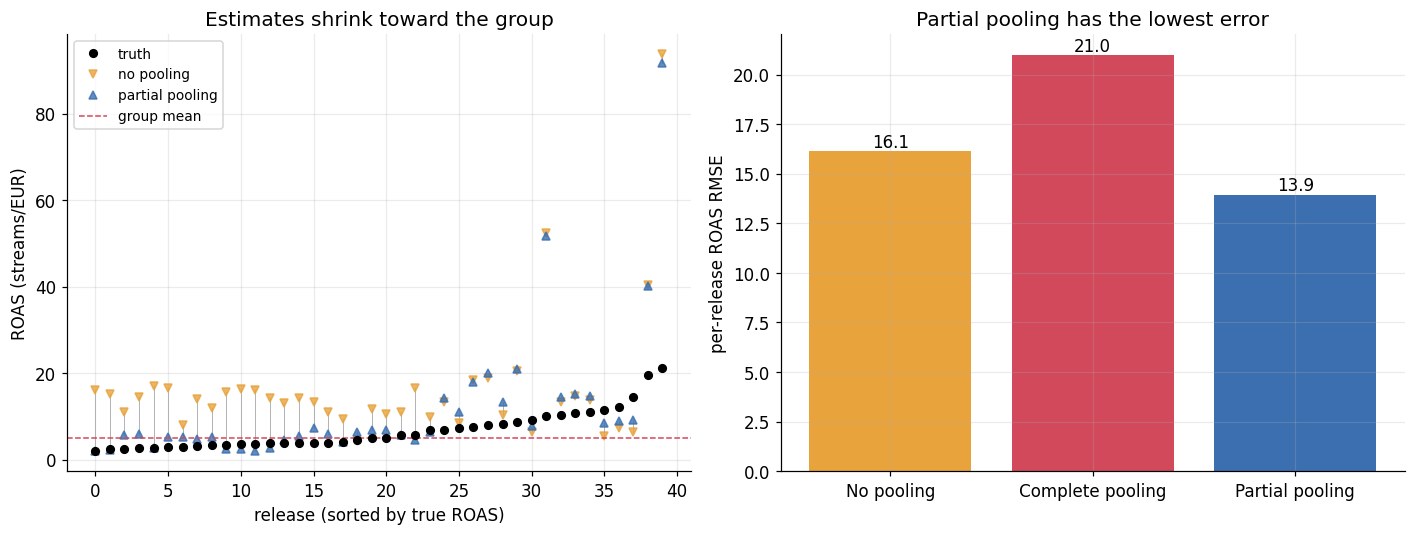

In [7]:
o=np.argsort(truth.roas.values)
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,5))
x=np.arange(R)
a1.plot(x, truth.roas.values[o], "o", color="k", ms=5, label="truth", zorder=5)
a1.plot(x, roas_est["none"][o], "v", color=GOLD, ms=5, alpha=.8, label="no pooling")
a1.plot(x, roas_est["partial"][o], "^", color=BLUE, ms=5, alpha=.8, label="partial pooling")
for i in x: a1.plot([i,i],[roas_est["none"][o][i],roas_est["partial"][o][i]],color=GREY,lw=.5,zorder=0)
a1.axhline(np.median(truth.roas),color=RED,ls="--",lw=1,label="group mean")
a1.set_xlabel("release (sorted by true ROAS)"); a1.set_ylabel("ROAS (streams/EUR)")
a1.set_title("Estimates shrink toward the group"); a1.legend(fontsize=9)
a2.bar(summary.index, summary["per-release ROAS RMSE"], color=[GOLD,RED,BLUE])
a2.set_title("Partial pooling has the lowest error"); a2.set_ylabel("per-release ROAS RMSE")
for i,v in enumerate(summary["per-release ROAS RMSE"]): a2.text(i,v,f"{v:.1f}",ha="center",va="bottom")
plt.tight_layout(); plt.show()

### Recovered hierarchy & response curves (partial pooling)

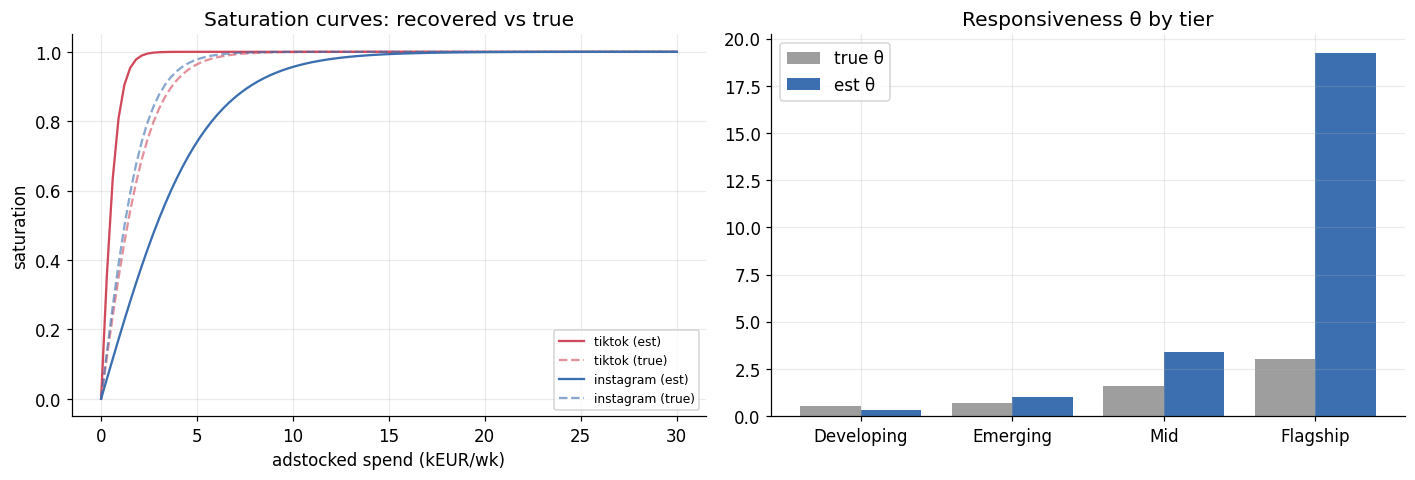

recovered γ (tier slope) = 1.06 (true 0.5); σ_θ = 0.69 (true 0.35)


In [8]:
ip=fits["partial"].posterior
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
# adstock / saturation recovery
xs=np.linspace(0,30,100)  # adstocked spend kEUR
for c,col in zip(chans,[RED,BLUE]):
    lam=float(ip[f"lam_{c}"].mean()); lam_t=meta["LAM"][c]
    a1.plot(xs,(1-np.exp(-lam*xs))/(1+np.exp(-lam*xs)),color=col,label=f"{c} (est)")
    a1.plot(xs,(1-np.exp(-lam_t*xs))/(1+np.exp(-lam_t*xs)),color=col,ls="--",alpha=.6,label=f"{c} (true)")
a1.set_title("Saturation curves: recovered vs true"); a1.set_xlabel("adstocked spend (kEUR/wk)")
a1.set_ylabel("saturation"); a1.legend(fontsize=8)
# theta by tier: estimated vs true
te=np.exp(ip["mu_theta"].values.mean()+ip["gamma_"].values.mean()*tier_z
         +ip["sig_theta"].values.mean()*ip["z"].mean(("chain","draw")).values)
tdf=pd.DataFrame({"tier":truth.tier,"true":truth.theta,"est":te})
xt=np.arange(4); tiers=["Developing","Emerging","Mid","Flagship"]
gt=tdf.groupby("tier")[["true","est"]].mean().loc[tiers]
a2.bar(xt-.2,gt["true"],.4,color=GREY,label="true θ"); a2.bar(xt+.2,gt["est"],.4,color=BLUE,label="est θ")
a2.set_xticks(xt); a2.set_xticklabels(tiers); a2.set_title("Responsiveness θ by tier"); a2.legend()
plt.tight_layout(); plt.show()
print(f"recovered γ (tier slope) = {float(ip['gamma_'].mean()):.2f} (true {meta['gamma']}); "
      f"σ_θ = {float(ip['sig_theta'].mean()):.2f} (true {meta['sig_theta']})")

## 6 · Calibrating the MMM with the geo experiment

Observational MMM struggles to pin the **absolute scale** of media effect (spend is
confounded with the launch). The fix from chapter 3: feed the **geo-experiment** result
in as a prior. Suppose the label ran clean geo lifts on its **flagship** releases and
measured their total incremental streams. We add that as a calibration term and refit.

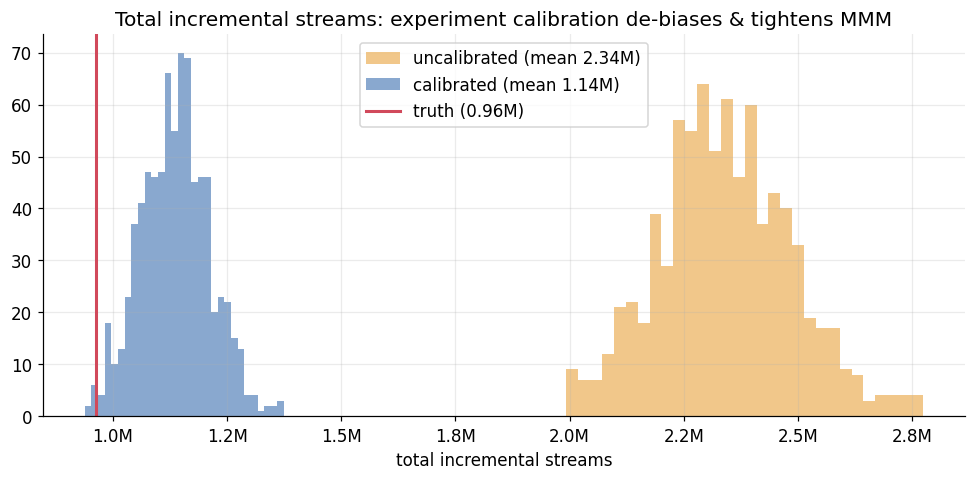

truth 962,386 | uncalibrated 2,340,379 (+143%) | calibrated 1,136,130 (+18%)


In [9]:
cal_rids=truth.query("tier=='Flagship'").rid.values
cal_idx=np.where(df.rid.isin(cal_rids).values)[0]
exp_val=truth.set_index("rid").loc[cal_rids,"incr"].sum()*np.random.default_rng(0).normal(1,0.05)
fit_cal=build("partial", calib=(cal_idx, exp_val, 0.08*exp_val))
def total_incr_draws(idata):
    m=idata.posterior["media"]; extra=[d for d in m.dims if d not in ("chain","draw")][0]
    return m.sum(extra).stack(s=("chain","draw")).values
unc=total_incr_draws(fits["partial"]); cal=total_incr_draws(fit_cal); true_tot=truth.incr.sum()
fig,ax=plt.subplots(figsize=(9,4.5))
ax.hist(unc,bins=30,color=GOLD,alpha=.6,label=f"uncalibrated (mean {unc.mean()/1e6:.2f}M)")
ax.hist(cal,bins=30,color=BLUE,alpha=.6,label=f"calibrated (mean {cal.mean()/1e6:.2f}M)")
ax.axvline(true_tot,color=RED,lw=2,label=f"truth ({true_tot/1e6:.2f}M)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v/1e6:.1f}M"))
ax.set_title("Total incremental streams: experiment calibration de-biases & tightens MMM")
ax.set_xlabel("total incremental streams"); ax.legend()
plt.tight_layout(); plt.show()
print(f"truth {true_tot:,.0f} | uncalibrated {unc.mean():,.0f} ({unc.mean()/true_tot-1:+.0%}) "
      f"| calibrated {cal.mean():,.0f} ({cal.mean()/true_tot-1:+.0%})")

## 7 · Budget optimization for next year

With the (calibrated) response curves we ask the money question: **given the same total
budget, how should we split it across releases and channels** to maximize incremental
streams? The optimum equalizes **marginal** ROAS. We optimize a **conservative
rebalancing** — each release-channel can move within **±50%** of its current spend (you
won't zero-out or triple a release overnight), holding the total fixed.

Same budget EUR 83,394: actual 1,382,862 -> optimized 1,919,894 incremental streams (+38.8%)


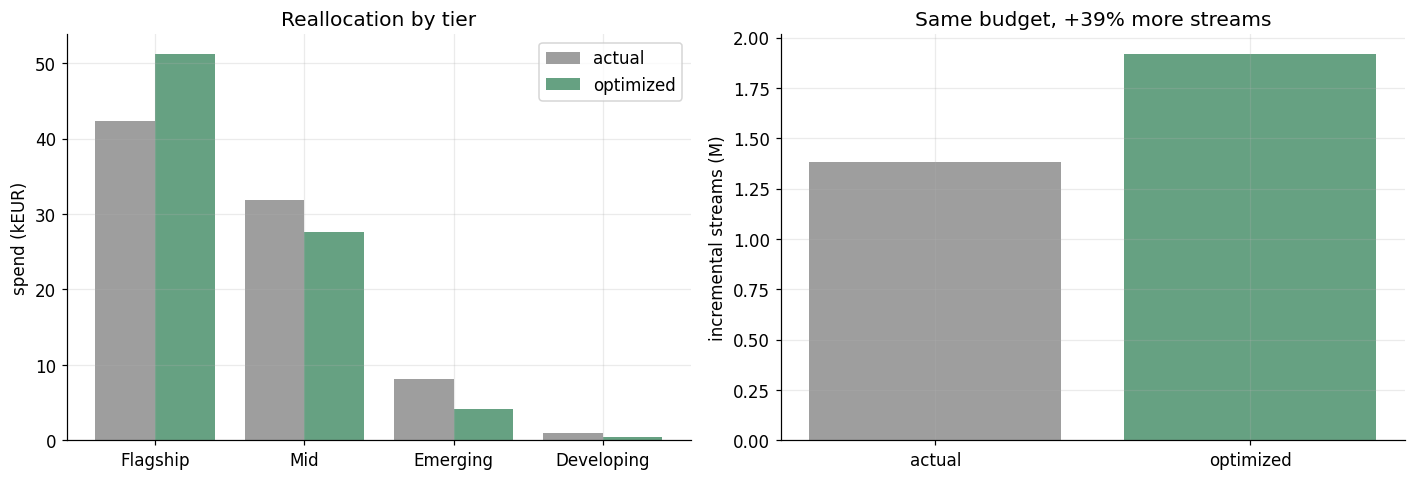

In [10]:
from scipy.optimize import minimize
P=fit_cal.posterior     # use the experiment-calibrated model
alpha={c:float(P[f"alpha_{c}"].mean()) for c in chans}
lam={c:float(P[f"lam_{c}"].mean()) for c in chans}
Ahat={c:float(P[f"A_{c}"].mean()) for c in chans}
theta_hat=np.exp(P["mu_theta"].values.mean()+P["gamma_"].values.mean()*tier_z
                 +P["sig_theta"].values.mean()*P["z"].mean(("chain","draw")).values)
wprof=np.exp(-0.35*np.arange(W)); wprof/=wprof.sum()
def rel_chan_incr(S, r, c):                  # incremental streams for total spend S on (r,c)
    sp=wprof*S/1000.0; ad=np.zeros(W); acc=0
    for i,v in enumerate(sp): acc=v+alpha[c]*acc; ad[i]=acc
    return Ahat[c]*theta_hat[r]*np.sum((1-np.exp(-lam[c]*ad))/(1+np.exp(-lam[c]*ad)))
budget=truth.spend.sum()
actual=np.array([[df[df.rid==r][c].sum() for c in chans] for r in range(R)])
def total(x):
    X=x.reshape(R,len(chans)); return sum(rel_chan_incr(X[r,j],r,c) for r in range(R) for j,c in enumerate(chans))
x0=actual.flatten()
bounds=[(0.5*v, 1.5*v) for v in x0]          # conservative +/-50% rebalancing band
res=minimize(lambda x:-total(x), x0, method="SLSQP", bounds=bounds,
             constraints={"type":"eq","fun":lambda x:x.sum()-budget}, options={"maxiter":300,"ftol":1e-1})
opt=res.x.reshape(R,len(chans)); base_incr=total(x0); opt_incr=total(res.x)
print(f"Same budget EUR {budget:,.0f}: actual {base_incr:,.0f} -> optimized {opt_incr:,.0f} incremental streams "
      f"({opt_incr/base_incr-1:+.1%})")
optdf=pd.DataFrame({"tier":truth.tier,"actual":actual.sum(1),"optimized":opt.sum(1)})
g=optdf.groupby("tier")[["actual","optimized"]].sum().loc[["Flagship","Mid","Emerging","Developing"]]
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.5))
xt=np.arange(4); a1.bar(xt-.2,g["actual"]/1e3,.4,color=GREY,label="actual"); a1.bar(xt+.2,g["optimized"]/1e3,.4,color=GREEN,label="optimized")
a1.set_xticks(xt); a1.set_xticklabels(g.index); a1.set_ylabel("spend (kEUR)"); a1.set_title("Reallocation by tier"); a1.legend()
a2.bar(["actual","optimized"],[base_incr/1e6,opt_incr/1e6],color=[GREY,GREEN])
a2.set_ylabel("incremental streams (M)"); a2.set_title(f"Same budget, {opt_incr/base_incr-1:+.0%} more streams")
plt.tight_layout(); plt.show()

## 8 · Takeaways & where this goes next

- **Pool, don't choose.** Per-release MMM overfits, one-size-fits-all underfits. **Partial
  pooling** gives every release its own ROAS while letting thin releases borrow strength —
  lowest error on per-release ROAS, and it recovers the tier structure.
- **Experiments calibrate models.** The geo lift from chapter 3, fed in as a prior,
  de-biases and tightens the MMM's absolute scale. Run experiments *and* MMM.
- **The payoff is allocation.** The fitted curves say where the next euro earns the most —
  reallocating the same budget toward responsive releases / unsaturated channels lifts
  incremental streams measurably, at zero extra cost.

### Next
- **Propagate uncertainty** into the optimizer (optimize expected streams over the full
  posterior, not point estimates) and add **risk-aware** allocation.
- **Time-varying & seasonal** baselines, plus **competition / organic virality** terms.
- **Multi-objective**: streams now vs. catalog/listener growth (LTV), and budget pacing.
- **Productionize** with `pymc-marketing`'s multidimensional MMM + a GeoLift experiment
  calendar feeding the priors each quarter.